# TPOSE24 Validation: Nested Domain Visualization

Task 6 — visualize TPOSE24 inside TPOSE6-Vel and assess interior drift.

The **5° buffer** is the strip of TPOSE6 *surrounding* the TPOSE24 domain (outside its boundaries).  
It shows what TPOSE6 looks like just outside TPOSE24, which is the source of the boundary conditions.

1. Domain overview map (TPOSE6 + TPOSE24 boundary + 5° buffer extent)
2. SSH and SST snapshots — TPOSE24 vs TPOSE6
3. Surface current snapshots
4. Animation of TPOSE24 vs TPOSE6 SSH → GIF
5. Drift time series: TPOSE24 domain mean vs TPOSE6 over same footprint
6. T/S profile comparison
7. End-of-run SSH difference map

**TPOSE24**: `/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month/` — 3-hourly, Oct–Dec 2012  
**TPOSE6-Vel**: `/data/SO3/edavenport/tpose6/sep2012/run_iter14/` — daily, Sep–Dec 2012  
**Kernel**: tpose

In [1]:
import os
os.makedirs('surface/3month', exist_ok=True)
os.makedirs('velocity/3month', exist_ok=True)
os.makedirs('TS/3month', exist_ok=True)
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
import cmocean.cm as cmo
from xmitgcm import open_mdsdataset
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

def cplot(ax, X, Y, data, cmap, vmin, vmax, **kwargs):
    """contourf with 50 levels between vmin and vmax."""
    levels = np.linspace(vmin, vmax, 51)
    return ax.contourf(X, Y, data, levels=levels, cmap=cmap, extend='both', **kwargs)

## 1. Load TPOSE24

In [ ]:
run24_dir = '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month'
iters24   = list(range(36, 26173, 36))  # 3-hourly, 3 months

ds24 = open_mdsdataset(
    data_dir=run24_dir, grid_dir=run24_dir,
    iters=iters24, prefix=['diag_state', 'diag_surf'],
    ref_date='2012-10-01', delta_t=300,
)
for c in ('XC', 'YC', 'Z', 'Zl', 'XG', 'YG'):
    if c in ds24.coords:
        ds24[c] = ds24[c].astype(float)
ds24 = ds24.where(ds24 != -999.0)
# Skip first 10 days (initialization shock)
ds24 = ds24.sel(time=slice('2012-10-11', None))

lon_min24 = float(ds24.XC.min())
lon_max24 = float(ds24.XC.max())
lat_min24 = float(ds24.YC.min())
lat_max24 = float(ds24.YC.max())

buf_deg = 5.0
# 5° buffer = strip of TPOSE6 surrounding TPOSE24 (outside the domain)
buf_lon_min = lon_min24 - buf_deg
buf_lon_max = lon_max24 + buf_deg
buf_lat_min = lat_min24 - buf_deg
buf_lat_max = lat_max24 + buf_deg

print(f'TPOSE24: {lon_min24:.2f}–{lon_max24:.2f}°E, {lat_min24:.2f}–{lat_max24:.2f}°N')
print(f'5° TPOSE6 buffer (outside): {buf_lon_min:.2f}–{buf_lon_max:.2f}°E, {buf_lat_min:.2f}–{buf_lat_max:.2f}°N')

## 2. Load TPOSE6

In [3]:
run6_dir  = '/data/SO3/edavenport/tpose6/sep2012/run_iter14'
grid6_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6'
iters6    = list(range(72, 8785, 72))  # 122 daily

ds6 = open_mdsdataset(
    data_dir=run6_dir, grid_dir=grid6_dir,
    iters=iters6, prefix=['diag_state', 'diag_surf'],
    ref_date='2012-09-01', delta_t=1200,
)
for c in ('XC', 'YC', 'Z', 'XG', 'YG'):
    if c in ds6.coords:
        ds6[c] = ds6[c].astype(float)
ds6 = ds6.where(ds6 != -999.0)

# TPOSE6 over the full buffer extent (TPOSE24 + 5° surrounding) — for spatial plots
ds6_buf = ds6.sel(
    XC=slice(buf_lon_min, buf_lon_max),
    YC=slice(buf_lat_min, buf_lat_max),
    time=slice('2012-10-01', '2012-12-31'),
)
# TPOSE6 over the TPOSE24 footprint only — for direct field comparison
ds6_tp24 = ds6.sel(
    XC=slice(lon_min24, lon_max24),
    YC=slice(lat_min24, lat_max24),
    time=slice('2012-10-01', '2012-12-31'),
)

print(f'TPOSE6 buffer extent: {float(ds6_buf.XC.min()):.2f}–{float(ds6_buf.XC.max()):.2f}°E, '
      f'{float(ds6_buf.YC.min()):.2f}–{float(ds6_buf.YC.max()):.2f}°N')
print(f'TPOSE6 Oct daily steps: {len(ds6_buf.time)}')

TPOSE6 buffer extent: 204.42–235.58°E, -10.42–15.42°N
TPOSE6 Oct daily steps: 92


## 3. Domain Overview Map

TPOSE6 SSH as background; black box = TPOSE24 domain; red dashed box = 5° TPOSE6 buffer surrounding TPOSE24.

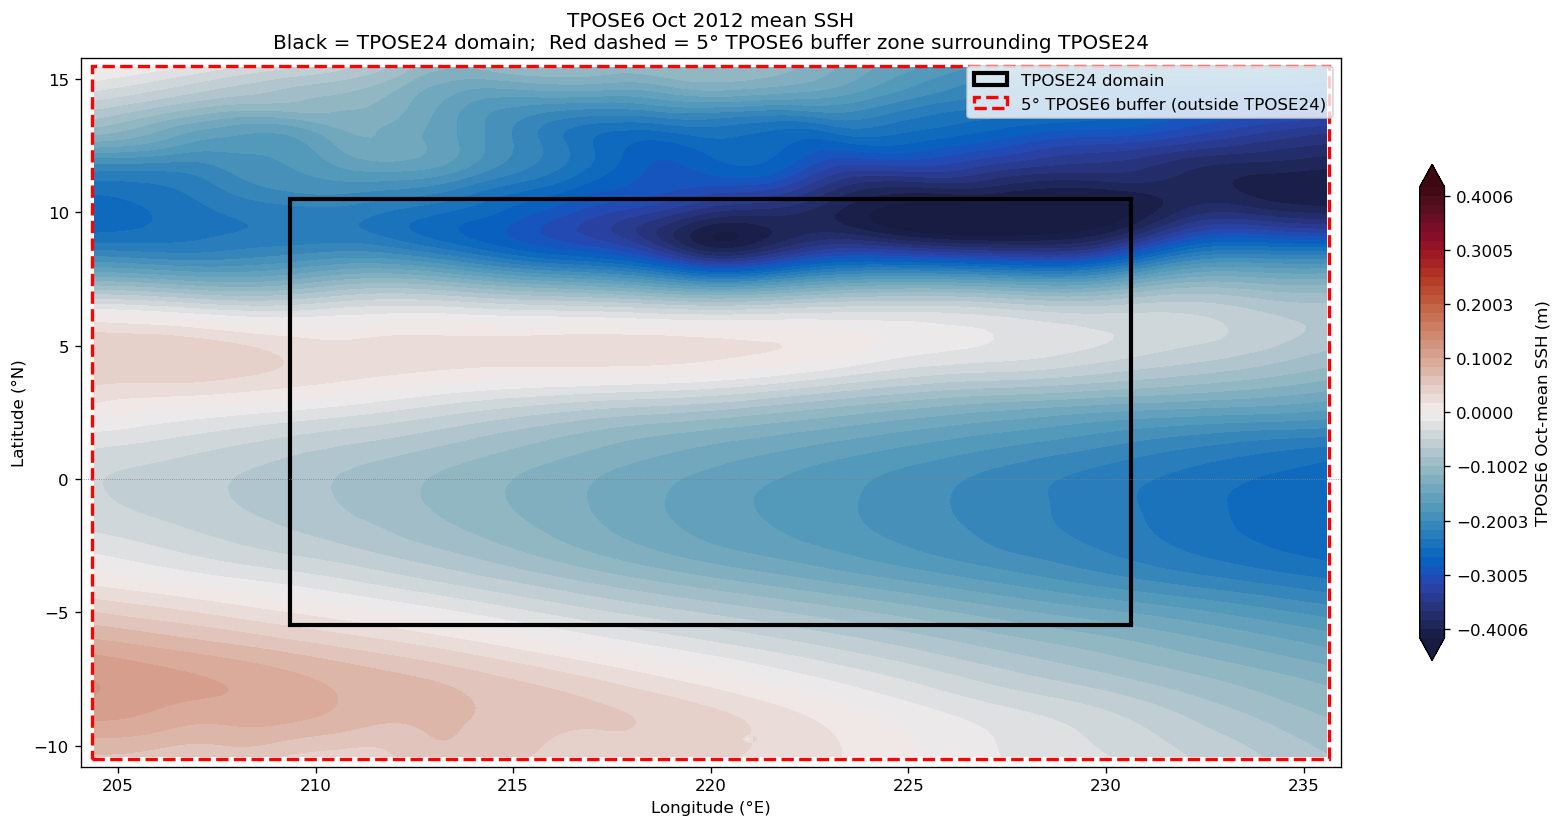

In [4]:
etan6_mean = ds6_buf.ETAN.mean('time').compute()

fig, ax = plt.subplots(figsize=(14, 7))
vmax = float(np.nanpercentile(np.abs(etan6_mean.values), 99))
cf = cplot(ax, ds6_buf.XC.values, ds6_buf.YC.values, etan6_mean.values,
           cmo.balance, -vmax, vmax)
plt.colorbar(cf, ax=ax, label='TPOSE6 Oct-mean SSH (m)', shrink=0.7)

# TPOSE24 domain boundary (black)
rect24 = mpatches.Rectangle(
    (lon_min24, lat_min24), lon_max24 - lon_min24, lat_max24 - lat_min24,
    lw=2.5, edgecolor='black', facecolor='none', label='TPOSE24 domain',
)
ax.add_patch(rect24)

# 5° buffer extent (red dashed) — this is the TPOSE6 region surrounding TPOSE24
rect_buf = mpatches.Rectangle(
    (buf_lon_min, buf_lat_min), buf_lon_max - buf_lon_min, buf_lat_max - buf_lat_min,
    lw=2, edgecolor='red', facecolor='none', ls='--',
    label='5° TPOSE6 buffer (outside TPOSE24)',
)
ax.add_patch(rect_buf)

ax.set_xlim(buf_lon_min - 0.3, buf_lon_max + 0.3)
ax.set_ylim(buf_lat_min - 0.3, buf_lat_max + 0.3)
ax.axhline(0, color='gray', lw=0.5, ls=':')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title('TPOSE6 Oct 2012 mean SSH\n'
             'Black = TPOSE24 domain;  Red dashed = 5° TPOSE6 buffer zone surrounding TPOSE24')
ax.legend()
plt.tight_layout()
plt.savefig('domain_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SSH and SST Snapshots: TPOSE24 vs TPOSE6

TPOSE6 panels show the full buffer extent. The black box marks the TPOSE24 domain boundary; red dashed marks the 5° buffer.

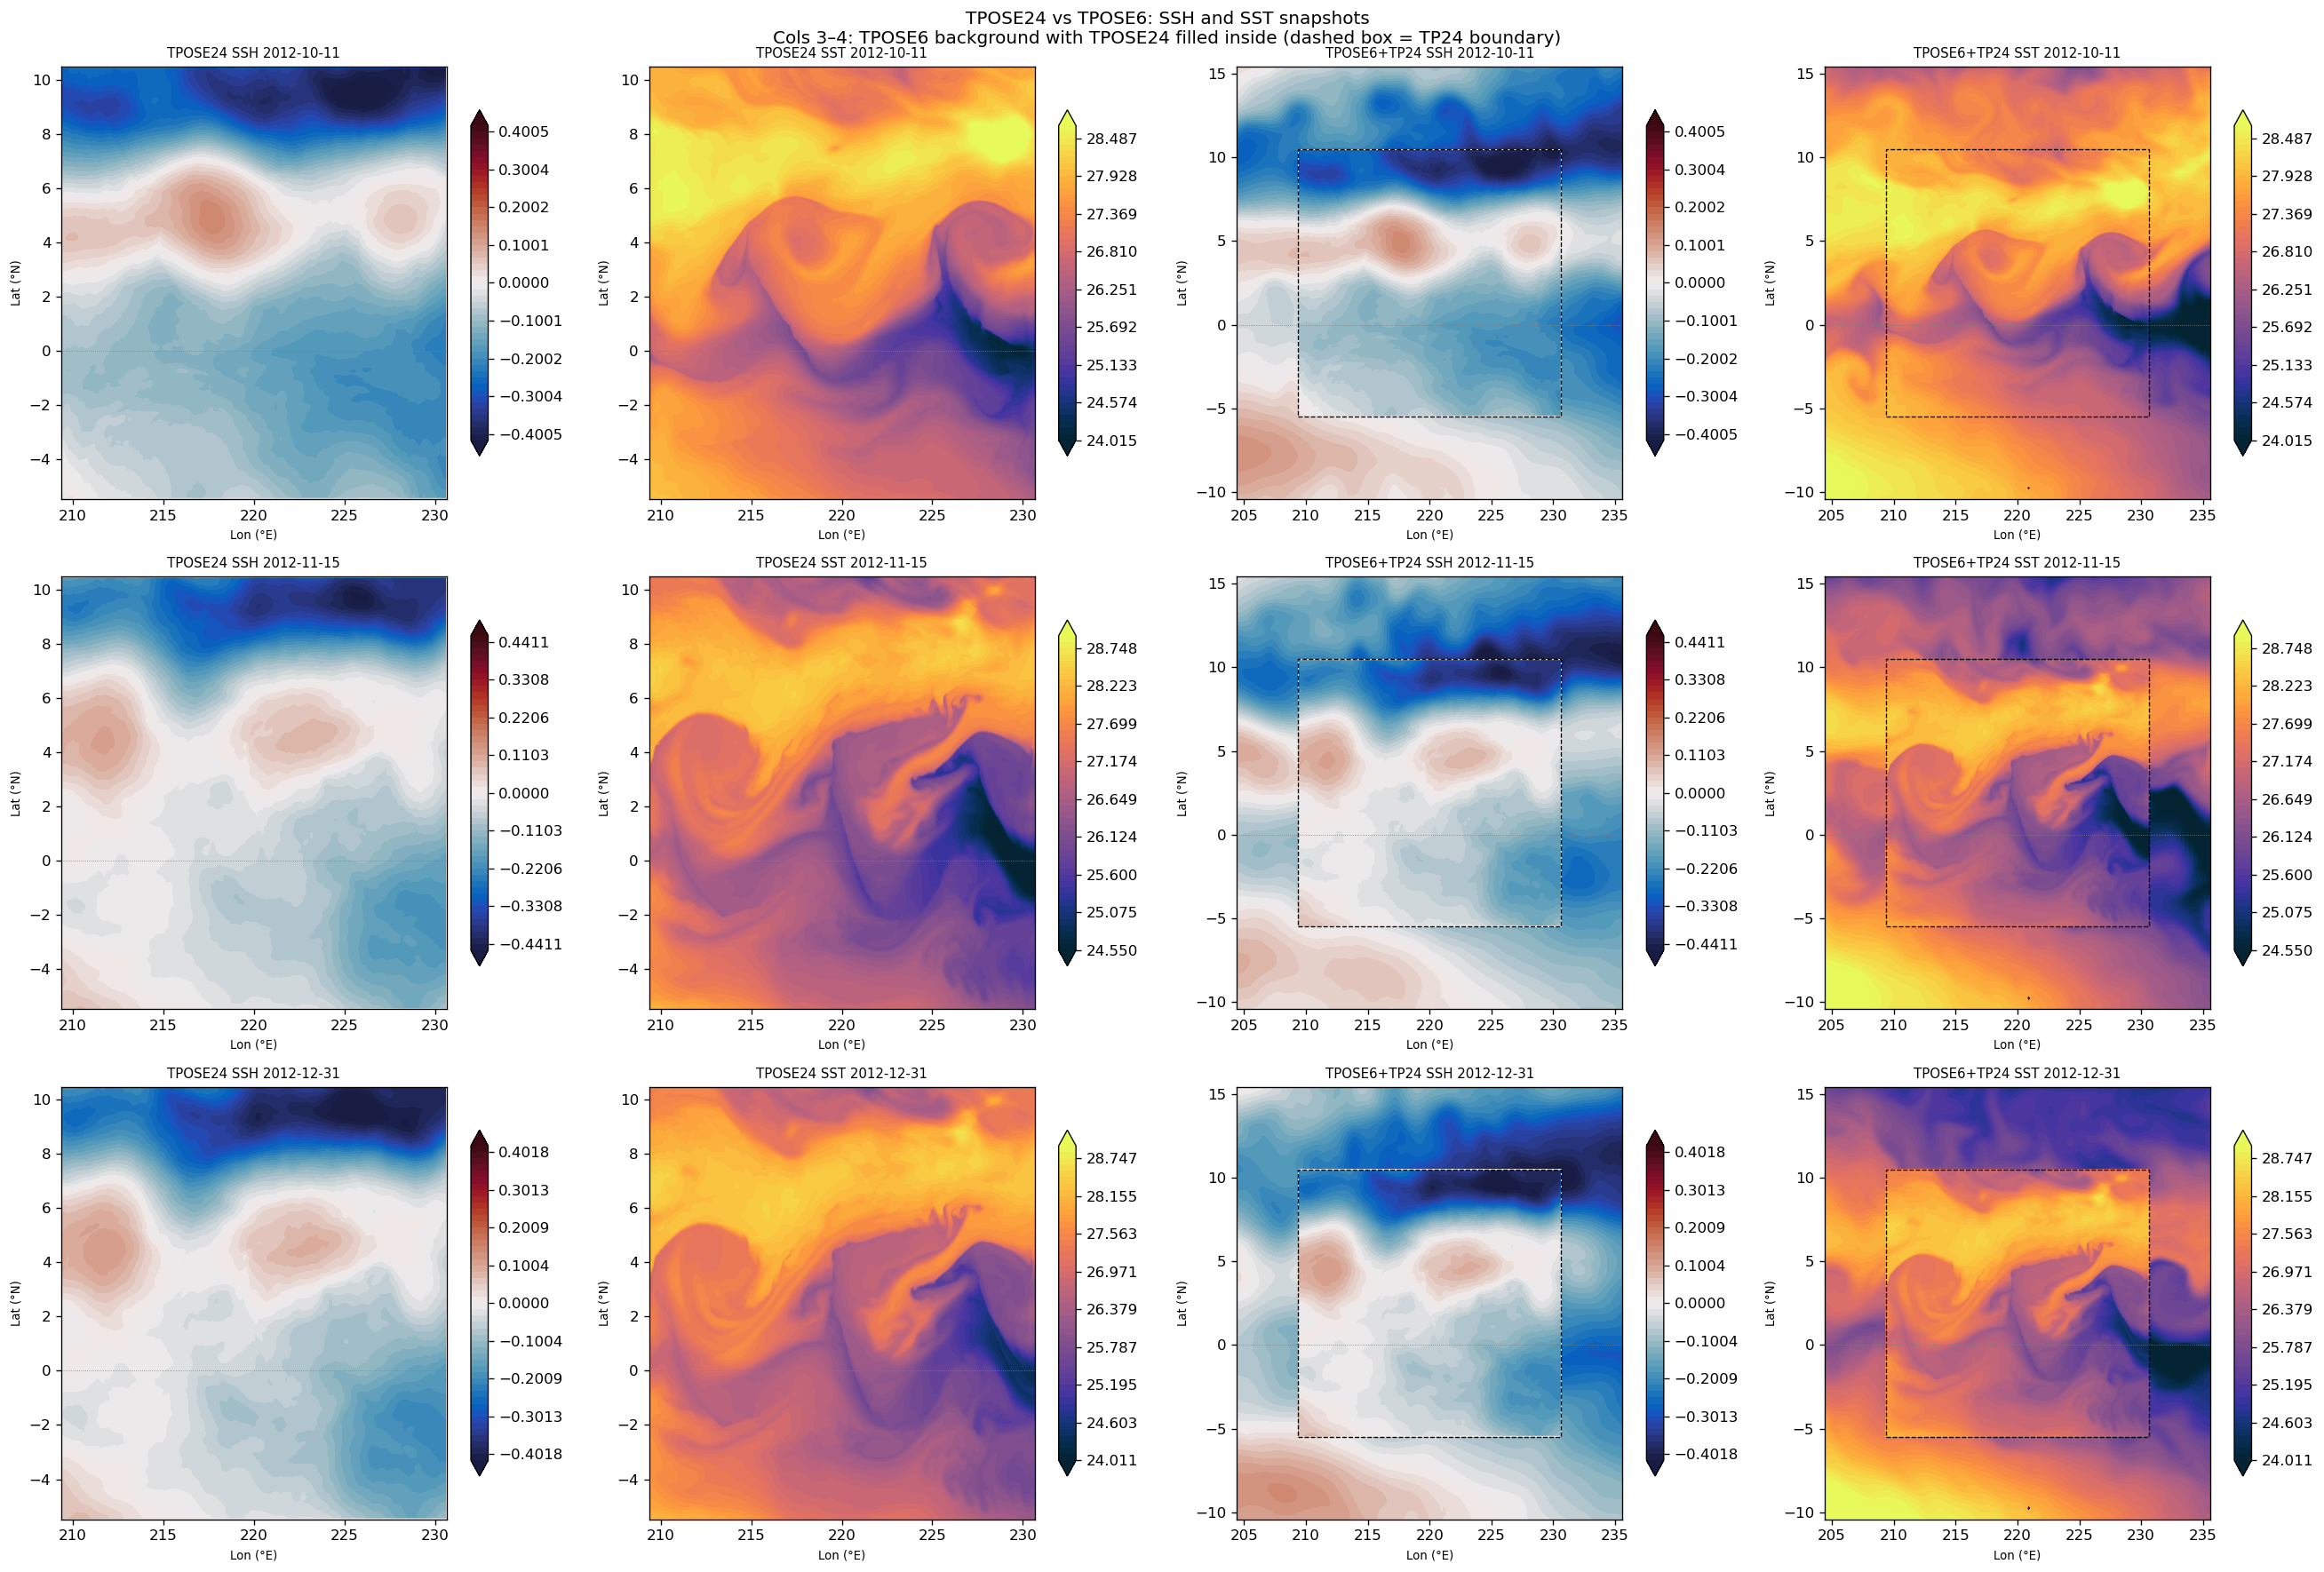

In [5]:
snap_dates = ['2012-10-11', '2012-11-15', '2012-12-31']

fig, axes = plt.subplots(len(snap_dates), 4,
                          figsize=(22, 5 * len(snap_dates)))

for row, date in enumerate(snap_dates):
    t24 = ds24.sel(time=date, method='nearest')
    t6  = ds6_buf.sel(time=date, method='nearest')

    ssh24 = t24.ETAN.compute()
    sst24 = t24.THETA.sel(Z=float(ds24.Z.max()), method='nearest').compute()
    ssh6  = t6.ETAN.compute()
    sst6  = t6.THETA.sel(Z=float(ds6.Z.max()), method='nearest').compute()

    ssh_vmax = max(float(np.nanpercentile(np.abs(ssh24.values), 99)),
                   float(np.nanpercentile(np.abs(ssh6.values),  99)))
    sst_vmin = min(float(np.nanpercentile(sst24.values, 1)), float(np.nanpercentile(sst6.values, 1)))
    sst_vmax = max(float(np.nanpercentile(sst24.values, 99)), float(np.nanpercentile(sst6.values, 99)))

    for col, (data, xx, yy, cmap, vmin, vmax, title) in enumerate([
        (ssh24, ds24.XC,    ds24.YC,    cmo.balance, -ssh_vmax, ssh_vmax, f'TPOSE24 SSH {date}'),
        (sst24, ds24.XC,    ds24.YC,    cmo.thermal, sst_vmin,  sst_vmax, f'TPOSE24 SST {date}'),
        (ssh6,  ds6_buf.XC, ds6_buf.YC, cmo.balance, -ssh_vmax, ssh_vmax, f'TPOSE6+TP24 SSH {date}'),
        (sst6,  ds6_buf.XC, ds6_buf.YC, cmo.thermal, sst_vmin,  sst_vmax, f'TPOSE6+TP24 SST {date}'),
    ]):
        ax = axes[row, col]
        cf = cplot(ax, xx.values, yy.values, data.values, cmap, vmin, vmax)
        plt.colorbar(cf, ax=ax, shrink=0.8)
        ax.axhline(0, color='gray', lw=0.5, ls=':')
        ax.set_xlabel('Lon (°E)', fontsize=8)
        ax.set_ylabel('Lat (°N)', fontsize=8)

        # On TPOSE6 panels (cols 2–3): overlay TPOSE24 data inside its domain
        if col >= 2:
            tp24_data = ssh24 if col == 2 else sst24
            cplot(ax, ds24.XC.values, ds24.YC.values, tp24_data.values, cmap, vmin, vmax)
            # TPOSE24 domain boundary (dashed black, thin)
            ax.add_patch(mpatches.Rectangle(
                (lon_min24, lat_min24), lon_max24 - lon_min24, lat_max24 - lat_min24,
                lw=0.8, edgecolor='black', facecolor='none', ls='--',
            ))

        ax.set_title(title, fontsize=9)

fig.suptitle('TPOSE24 vs TPOSE6: SSH and SST snapshots\n'
             'Cols 3–4: TPOSE6 background with TPOSE24 filled inside (dashed box = TP24 boundary)',
             fontsize=12)
plt.tight_layout()
plt.savefig('surface/3month/snapshots_SSH_SST.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Surface Current Snapshots

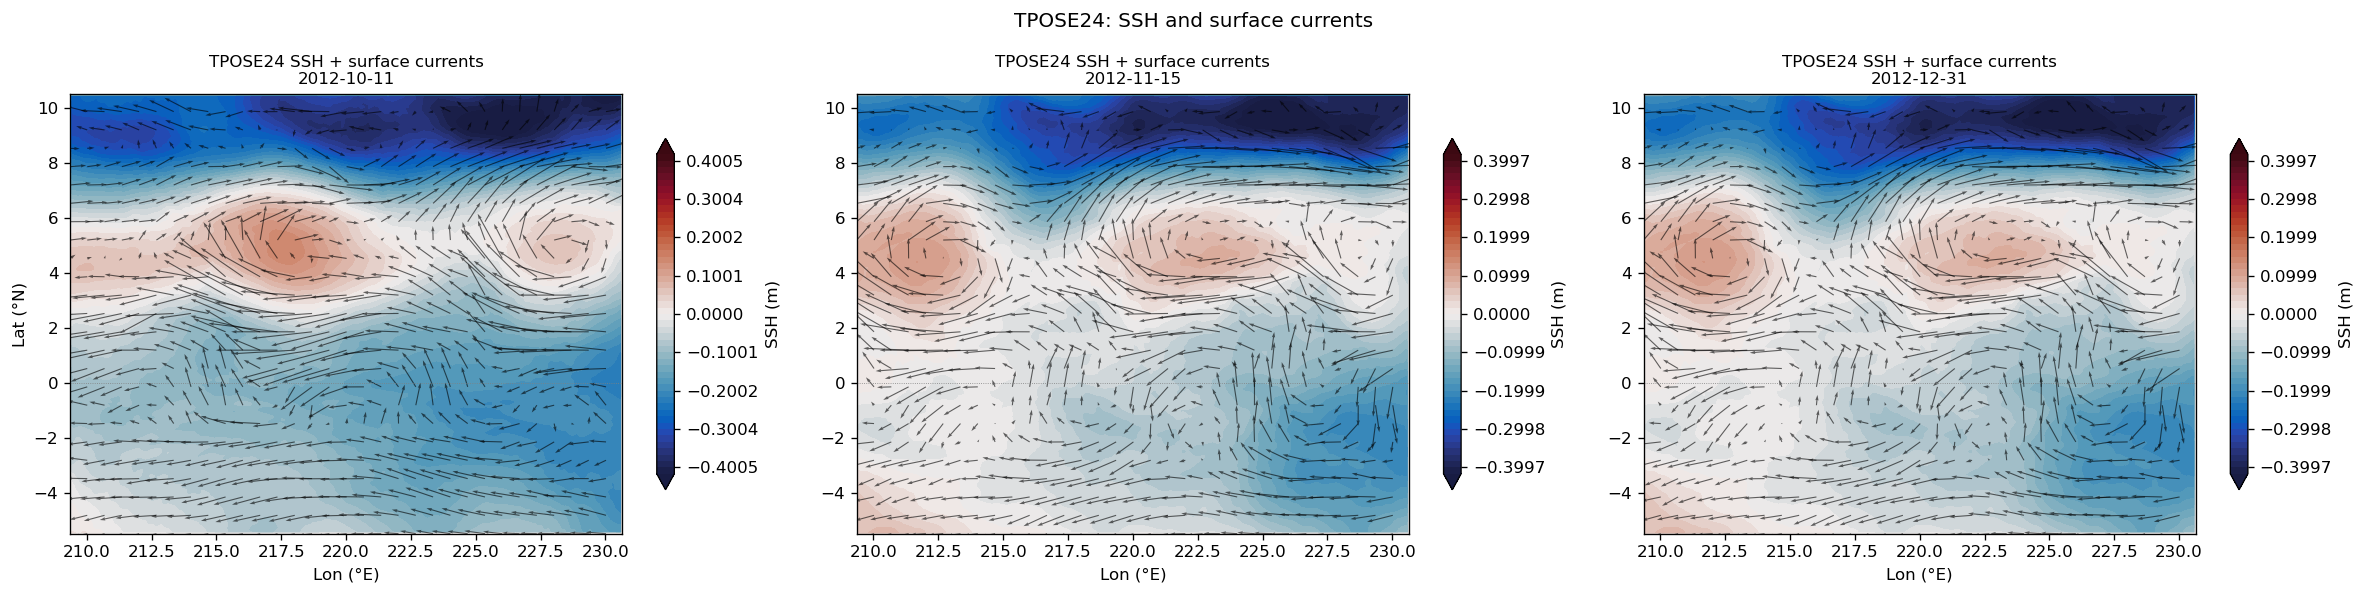

In [6]:
skip_deg   = 0.67
dx24       = float(ds24.XC[1] - ds24.XC[0])
skip_cells = max(1, int(skip_deg / dx24))

fig, axes = plt.subplots(1, len(snap_dates), figsize=(20, 5))

for ax, date in zip(axes, snap_dates):
    t24    = ds24.sel(time=date, method='nearest')
    ssh    = t24.ETAN.compute()
    u_surf = t24.UVEL.sel(Z=float(ds24.Z.max()), method='nearest').compute()
    v_surf = t24.VVEL.sel(Z=float(ds24.Z.max()), method='nearest').compute()

    ssh_vmax = float(np.nanpercentile(np.abs(ssh.values), 99))
    cf = cplot(ax, ds24.XC.values, ds24.YC.values, ssh.values,
               cmo.balance, -ssh_vmax, ssh_vmax)
    plt.colorbar(cf, ax=ax, label='SSH (m)', shrink=0.8)

    xs     = ds24.XC.values[::skip_cells]
    ys     = ds24.YC.values[::skip_cells]
    u_xc   = u_surf.interp(XG=ds24.XC).values[::skip_cells, ::skip_cells]
    v_yc   = v_surf.interp(YG=ds24.YC).values[::skip_cells, ::skip_cells]
    ax.quiver(xs, ys, u_xc, v_yc, scale=10, width=0.002, color='k', alpha=0.6)

    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_title(f'TPOSE24 SSH + surface currents\n{date}', fontsize=10)
    ax.set_xlabel('Lon (°E)')

axes[0].set_ylabel('Lat (°N)')
fig.suptitle('TPOSE24: SSH and surface currents', fontsize=12)
plt.tight_layout()
plt.savefig('velocity/3month/snapshots_surface_currents.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Load surface fields for animation

In [7]:
print('Loading ETAN (all 720 hourly)...')
etan_all = ds24.ETAN.compute()
print('Loading surface SST...')
sst_all  = ds24.THETA.sel(Z=float(ds24.Z.max()), method='nearest').compute()
print('Done.')

Loading ETAN (all 720 hourly)...


Loading surface SST...


Done.


## 7. Animation: TPOSE24 vs TPOSE6 SSH (daily)

Left panel: TPOSE24 daily mean SSH.  Right panel: TPOSE6 SSH over the full buffer extent, with the TPOSE24 domain and 5° buffer marked.

In [8]:
etan24_daily = etan_all.resample(time='1D').mean().compute()
etan6_daily  = ds6_buf.ETAN.compute()
time_daily   = etan24_daily.time.values

vmax_ssh = max(
    float(np.nanpercentile(np.abs(etan24_daily.values), 99)),
    float(np.nanpercentile(np.abs(etan6_daily.values),  99)),
)
ssh_levels = np.linspace(-vmax_ssh, vmax_ssh, 51)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

def draw_frame(i):
    for ax in axes:
        for coll in ax.collections:
            coll.remove()

    t6_snap = etan6_daily.sel(time=time_daily[i], method='nearest')

    axes[0].contourf(ds24.XC.values, ds24.YC.values,
                     etan24_daily.isel(time=i).values,
                     levels=ssh_levels, cmap=cmo.balance, extend='both')
    axes[1].contourf(ds6_buf.XC.values, ds6_buf.YC.values,
                     t6_snap.values,
                     levels=ssh_levels, cmap=cmo.balance, extend='both')

    title_txt.set_text(str(time_daily[i])[:10])
    return axes[0].collections + axes[1].collections + [title_txt]

# First frame
cf24 = axes[0].contourf(ds24.XC.values, ds24.YC.values,
                         etan24_daily.isel(time=0).values,
                         levels=ssh_levels, cmap=cmo.balance, extend='both')
plt.colorbar(cf24, ax=axes[0], label='SSH (m)')

cf6 = axes[1].contourf(ds6_buf.XC.values, ds6_buf.YC.values,
                        etan6_daily.isel(time=0).values,
                        levels=ssh_levels, cmap=cmo.balance, extend='both')
plt.colorbar(cf6, ax=axes[1], label='SSH (m)')

# Annotations on TPOSE6 panel
axes[1].add_patch(mpatches.Rectangle(
    (lon_min24, lat_min24), lon_max24 - lon_min24, lat_max24 - lat_min24,
    lw=2, edgecolor='black', facecolor='none', label='TPOSE24',
))
axes[1].add_patch(mpatches.Rectangle(
    (buf_lon_min, buf_lat_min), buf_lon_max - buf_lon_min, buf_lat_max - buf_lat_min,
    lw=1.5, edgecolor='red', facecolor='none', ls='--', label='5° buffer',
))
axes[1].legend(loc='upper right', fontsize=8)

for ax, title in zip(axes, ['TPOSE24 SSH (1/24°, daily mean)', 'TPOSE6-Vel SSH (1/6°)']):
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Lon (°E)')
    ax.set_ylabel('Lat (°N)')
    ax.set_title(title)

title_txt = fig.suptitle(str(time_daily[0])[:10], fontsize=12)

anim = animation.FuncAnimation(fig, draw_frame, frames=len(time_daily),
                                interval=300, blit=False)
anim.save('surface/3month/tpose24_vs_tpose6_SSH.gif',
          writer=animation.PillowWriter(fps=4), dpi=100)
print('Saved: tpose24_vs_tpose6_SSH.gif')
plt.close()

Saved: tpose24_vs_tpose6_SSH.gif


In [ ]:
# TPOSE24 SSH + SST animation (12-hourly, 4×3h)
step = 4
etan_anim = etan_all.isel(time=slice(None, None, step))
sst_anim  = sst_all.isel(time=slice(None, None, step))
time_anim = ds24.time.values[::step]

ssh_vmax2 = float(np.nanpercentile(np.abs(etan_anim.values), 99.5))
sst_vmin  = float(np.nanpercentile(sst_anim.values, 1))
sst_vmax  = float(np.nanpercentile(sst_anim.values, 99))
lev_ssh   = np.linspace(-ssh_vmax2, ssh_vmax2, 51)
lev_sst   = np.linspace(sst_vmin, sst_vmax, 51)

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
cf_s = axes2[0].contourf(ds24.XC.values, ds24.YC.values,
                          etan_anim.isel(time=0).values,
                          levels=lev_ssh, cmap=cmo.balance, extend='both')
plt.colorbar(cf_s, ax=axes2[0], label='SSH (m)')
cf_t = axes2[1].contourf(ds24.XC.values, ds24.YC.values,
                          sst_anim.isel(time=0).values,
                          levels=lev_sst, cmap=cmo.thermal, extend='both')
plt.colorbar(cf_t, ax=axes2[1], label='SST (°C)')

for ax, title in zip(axes2, ['SSH', 'SST']):
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Lon (°E)')
    ax.set_ylabel('Lat (°N)')
    ax.set_title(title)

title2 = fig2.suptitle(str(time_anim[0])[:13], fontsize=12)

def draw_frame2(i):
    for ax in axes2:
        for coll in ax.collections:
            coll.remove()
    axes2[0].contourf(ds24.XC.values, ds24.YC.values,
                      etan_anim.isel(time=i).values,
                      levels=lev_ssh, cmap=cmo.balance, extend='both')
    axes2[1].contourf(ds24.XC.values, ds24.YC.values,
                      sst_anim.isel(time=i).values,
                      levels=lev_sst, cmap=cmo.thermal, extend='both')
    title2.set_text(str(time_anim[i])[:13])
    return axes2[0].collections + axes2[1].collections + [title2]

anim2 = animation.FuncAnimation(fig2, draw_frame2, frames=len(time_anim),
                                  interval=150, blit=False)
anim2.save('tpose24_surface.gif',
           writer=animation.PillowWriter(fps=6), dpi=100)
print('Saved: tpose24_surface.gif')
plt.close()

## 8. Interior Drift Analysis

Compare TPOSE24 domain-mean SSH/SST to TPOSE6 over the same footprint.  
Divergence reveals how much TPOSE24 has drifted from the parent model over 30 days.

In [ ]:
# TPOSE24 domain-mean time series
ssh24_mean = etan_all.mean(dim=['XC', 'YC'])
sst24_mean = sst_all.mean(dim=['XC', 'YC'])

# TPOSE6 over the TPOSE24 footprint (direct comparison)
ssh6_same = ds6_tp24.ETAN.mean(dim=['XC', 'YC']).compute()
sst6_same = ds6_tp24.THETA.sel(Z=float(ds6.Z.max()), method='nearest').mean(dim=['XC', 'YC']).compute()

t24_days = (ds24.time.values  - ds24.time.values[0]) / np.timedelta64(1, 'D')
t6_days  = (ds6_tp24.time.values - ds24.time.values[0]) / np.timedelta64(1, 'D')

print('TPOSE24 3-hourly points:', len(t24_days))
print('TPOSE6 daily points (Oct–Dec):', len(t6_days))

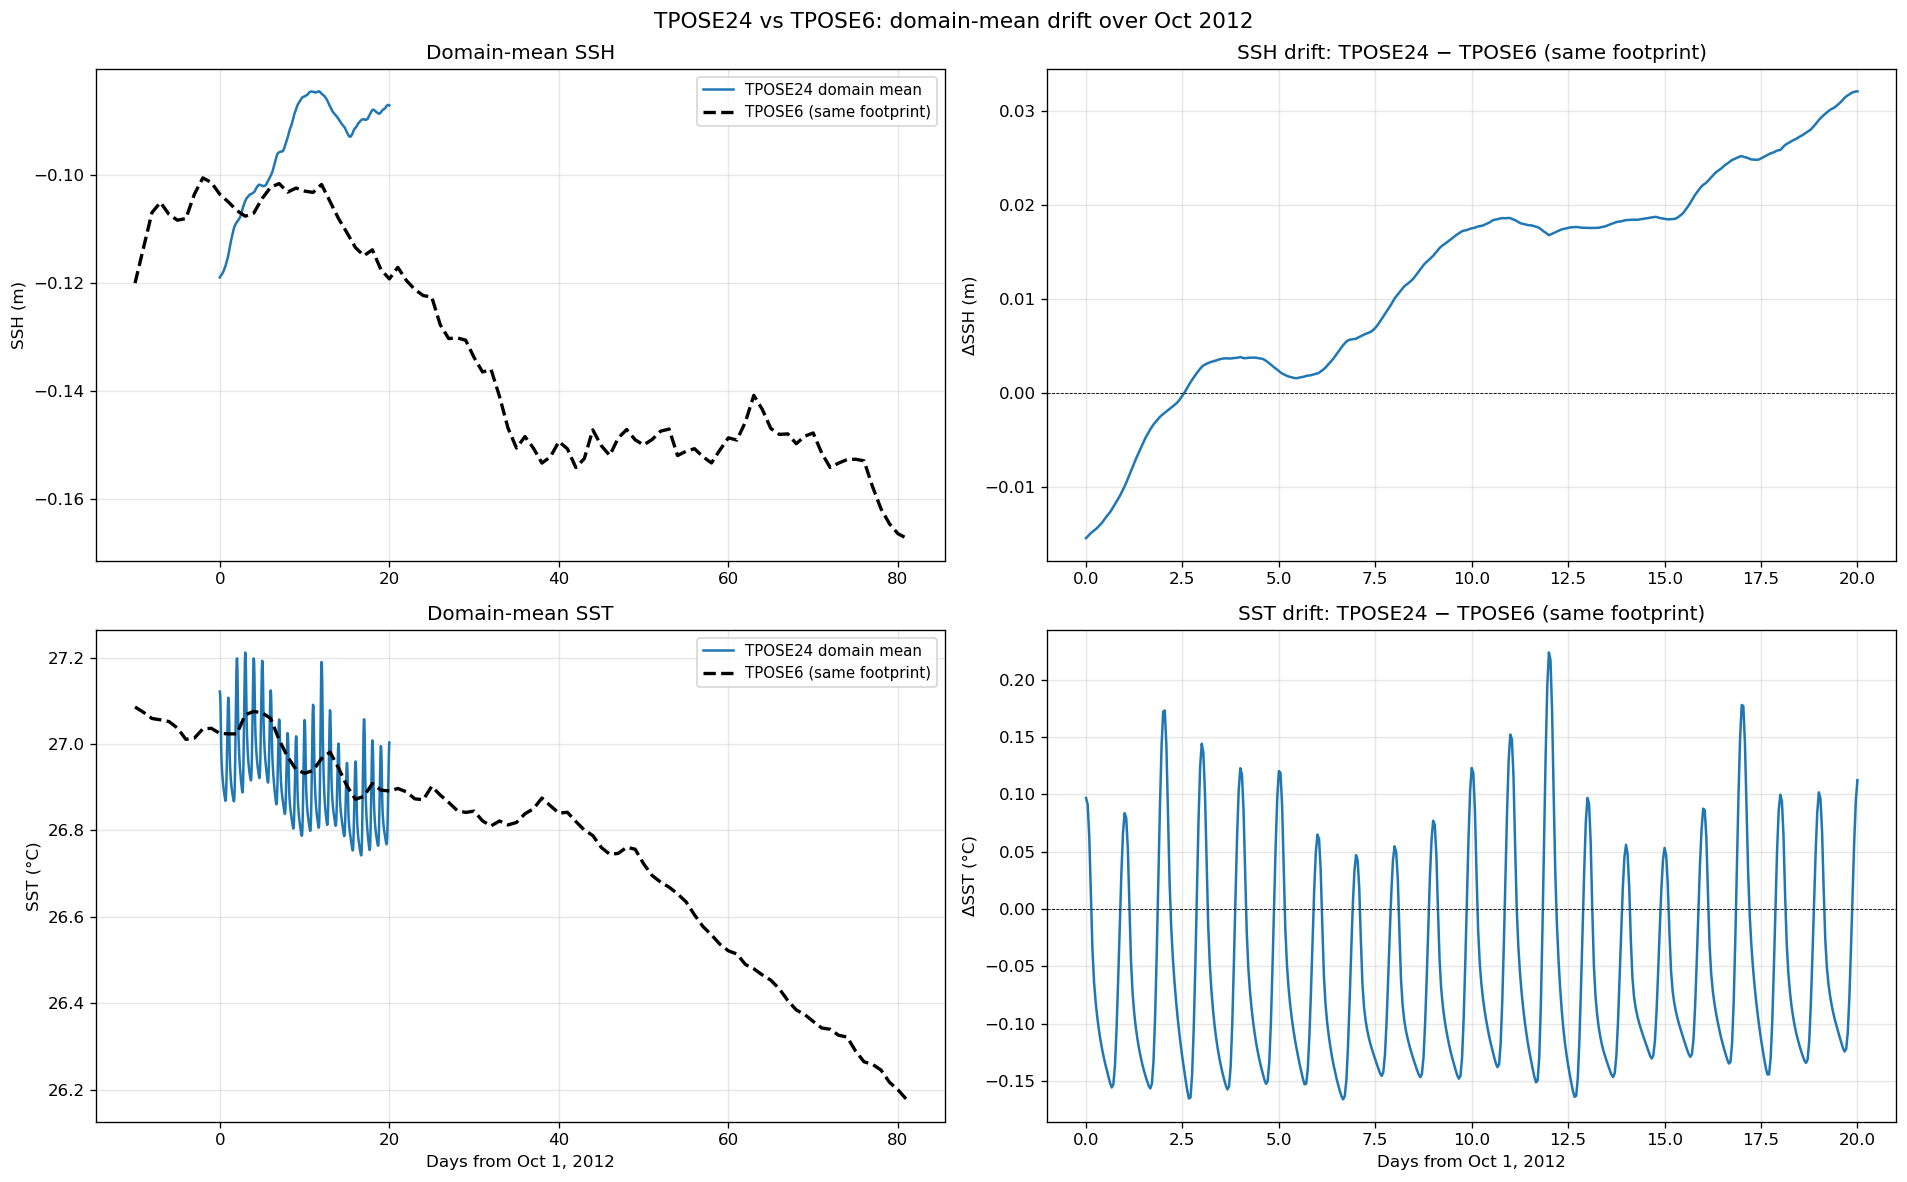

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# SSH
axes[0, 0].plot(t24_days, ssh24_mean.values, 'C0', lw=1.5, label='TPOSE24 domain mean')
axes[0, 0].plot(t6_days,  ssh6_same.values,  'k--', lw=2, label='TPOSE6 (same footprint)')
axes[0, 0].set_ylabel('SSH (m)')
axes[0, 0].set_title('Domain-mean SSH')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# SSH drift
ssh6_interp = np.interp(t24_days, t6_days, ssh6_same.values)
axes[0, 1].plot(t24_days, ssh24_mean.values - ssh6_interp, 'C0', lw=1.5)
axes[0, 1].axhline(0, color='k', lw=0.5, ls='--')
axes[0, 1].set_ylabel('ΔSSH (m)')
axes[0, 1].set_title('SSH drift: TPOSE24 − TPOSE6 (same footprint)')
axes[0, 1].grid(True, alpha=0.3)

# SST
axes[1, 0].plot(t24_days, sst24_mean.values, 'C0', lw=1.5, label='TPOSE24 domain mean')
axes[1, 0].plot(t6_days,  sst6_same.values,  'k--', lw=2, label='TPOSE6 (same footprint)')
axes[1, 0].set_ylabel('SST (°C)')
axes[1, 0].set_xlabel('Days from Oct 1, 2012')
axes[1, 0].set_title('Domain-mean SST')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# SST drift
sst6_interp = np.interp(t24_days, t6_days, sst6_same.values)
axes[1, 1].plot(t24_days, sst24_mean.values - sst6_interp, 'C0', lw=1.5)
axes[1, 1].axhline(0, color='k', lw=0.5, ls='--')
axes[1, 1].set_ylabel('ΔSST (°C)')
axes[1, 1].set_xlabel('Days from Oct 1, 2012')
axes[1, 1].set_title('SST drift: TPOSE24 − TPOSE6 (same footprint)')
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('TPOSE24 vs TPOSE6: domain-mean drift over Oct 2012', fontsize=13)
plt.tight_layout()
plt.savefig('surface/3month/interior_drift_SSH_SST.png', dpi=150, bbox_inches='tight')
plt.show()

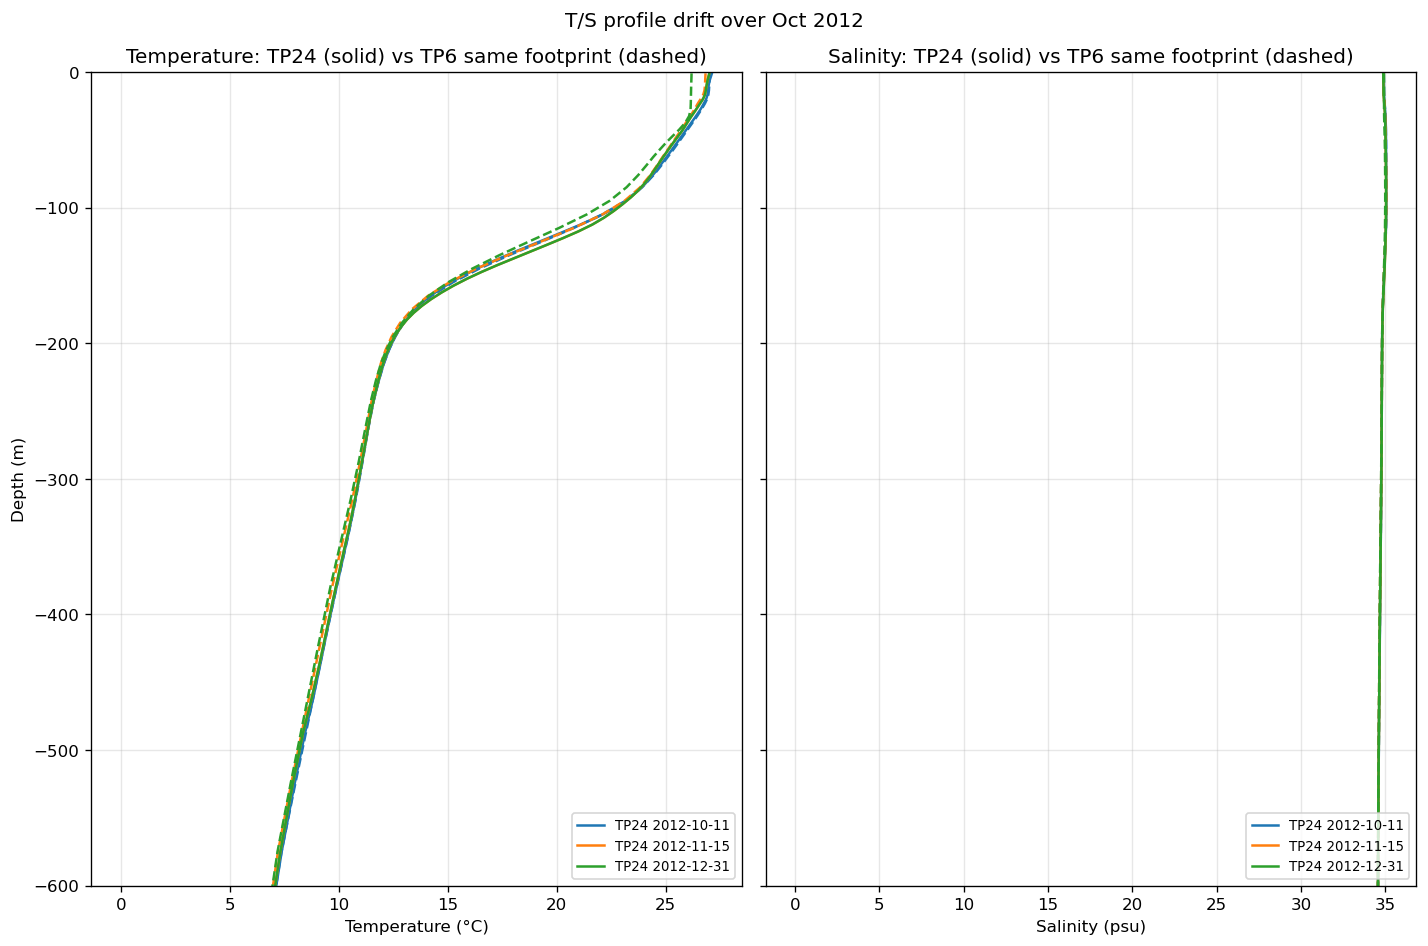

In [12]:
# T/S mean profiles: TPOSE24 domain mean vs TPOSE6 over same footprint
dates_check = ['2012-10-11', '2012-11-15', '2012-12-31']
colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

for date, color in zip(dates_check, colors):
    T24 = (ds24.THETA.sel(time=date, method='nearest')
           .mean(dim=['XC', 'YC']).compute())
    S24 = (ds24.SALT.sel(time=date, method='nearest')
           .mean(dim=['XC', 'YC']).compute())
    T6  = (ds6_tp24.THETA.sel(time=date, method='nearest')
           .mean(dim=['XC', 'YC']).compute())
    S6  = (ds6_tp24.SALT.sel(time=date, method='nearest')
           .mean(dim=['XC', 'YC']).compute())

    axes[0].plot(T24.values, ds24.Z.values,          color=color, lw=1.5, label=f'TP24 {date}')
    axes[0].plot(T6.values,  ds6.Z.values[:len(T6)], color=color, ls='--', lw=1.5)
    axes[1].plot(S24.values, ds24.Z.values,          color=color, lw=1.5, label=f'TP24 {date}')
    axes[1].plot(S6.values,  ds6.Z.values[:len(S6)], color=color, ls='--', lw=1.5)

for ax, xlabel in zip(axes, ['Temperature (°C)', 'Salinity (psu)']):
    ax.set_ylim(-600, 0)
    ax.set_xlabel(xlabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Temperature: TP24 (solid) vs TP6 same footprint (dashed)')
axes[1].set_title('Salinity: TP24 (solid) vs TP6 same footprint (dashed)')

fig.suptitle('T/S profile drift over Oct 2012', fontsize=12)
plt.tight_layout()
plt.savefig('TS/3month/interior_drift_TS_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. End-of-run SSH difference map

TPOSE6 regridded to the TPOSE24 grid. The buffer zone (red dashed) is visible on the difference panel.

In [ ]:
ssh24_final  = etan_all.sel(time='2012-12-31', method='nearest')
ssh6_final   = ds6_tp24.ETAN.sel(time='2012-12-31', method='nearest').compute()
ssh6_on_tp24 = ssh6_final.interp(XC=ds24.XC, YC=ds24.YC, method='linear')
ssh_diff     = ssh24_final - ssh6_on_tp24

vmax_d = float(np.nanpercentile(np.abs(ssh_diff.values), 99))
vmax_s = max(float(np.nanpercentile(np.abs(ssh24_final.values), 99)),
             float(np.nanpercentile(np.abs(ssh6_on_tp24.values), 99)))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, data, cmap, vmin, vmax, title in [
    (axes[0], ssh24_final,  cmo.balance, -vmax_s, vmax_s, 'TPOSE24 SSH (Dec 31)'),
    (axes[1], ssh6_on_tp24, cmo.balance, -vmax_s, vmax_s, 'TPOSE6 SSH (Dec 31, regridded)'),
    (axes[2], ssh_diff,     cmo.balance, -vmax_d, vmax_d, 'Difference  TP24 − TP6'),
]:
    cf = cplot(ax, ds24.XC.values, ds24.YC.values, data.values, cmap, vmin, vmax)
    plt.colorbar(cf, ax=ax, label='SSH (m)', shrink=0.8)
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Lon (°E)')

axes[0].set_ylabel('Lat (°N)')
fig.suptitle('End-of-run SSH: TPOSE24 vs TPOSE6', fontsize=12)
plt.tight_layout()
plt.savefig('surface/3month/ssh_diff_final.png', dpi=150, bbox_inches='tight')
plt.show()